## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [9]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


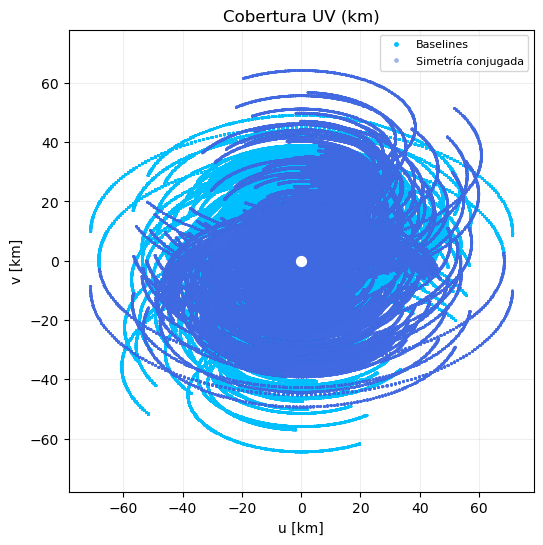

In [39]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/skalow.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T00:00:00",
    "utc_end": "2023-11-21T12:00:00",
    "step_min": 5,
    "n_freqs": 2,
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    
    "n_sources": 10,
    "max_offset_deg": 1, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, frequencies, baselines_enu, _ , _ = visibilities_simulation(SKA_LOW_AA1)

plot_uv_coverage(uvw, unit='km')

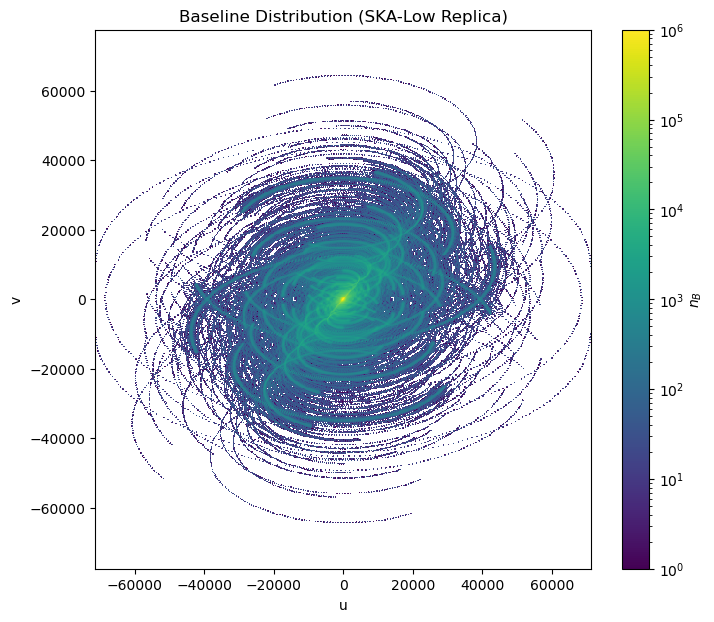

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

def plot_uv_density_paper_style(uvw, bins=512):
    # Extraemos u y v (asegúrate de que estén en las unidades deseadas, ej. baselines)
    u = uvw[..., 0].flatten()
    v = uvw[..., 1].flatten()
    
    # El paper asume simetría conjugada completa
    u_full = np.concatenate([u, -u])
    v_full = np.concatenate([v, -v])
    
    plt.figure(figsize=(8, 7))
    
    # Histograma 2D con escala logarítmica para n_B
    # El rango debe coincidir con la extensión de tus baselines (ej. -250 a 250)
    h = plt.hist2d(u_full, v_full, bins=bins, 
                   cmap='viridis', # O 'YlGnBu_r' para un look similar
                   norm=colors.LogNorm(vmin=1, vmax=1e6)) # Rango 10^0 a 10^6 como el paper
    
    plt.colorbar(label='$n_B$')
    plt.xlabel('u')
    plt.ylabel('v')
    plt.title('Baseline Distribution (SKA-Low Replica)')
    plt.axis('equal')
    plt.show()

plot_uv_density_paper_style(uvw, 512)